# Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# Data Augmentation

In [12]:
# Training transforms with augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Validation/Test transforms (no augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


# Dataset loading and spliting

In [13]:
dataset_root = "/kaggle/input/realwaste/realwaste-main/RealWaste"

# Load full dataset once for label extraction
full_dataset = datasets.ImageFolder(root=dataset_root, transform=train_transform)
targets = np.array([s[1] for s in full_dataset.samples])

# Stratified split
train_idx, temp_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.30,
    stratify=targets,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=targets[temp_idx],
    random_state=42
)

# Subset datasets with correct transforms
train_dataset = datasets.ImageFolder(root=dataset_root, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=dataset_root, transform=val_test_transform)
test_dataset  = datasets.ImageFolder(root=dataset_root, transform=val_test_transform)

train_set = Subset(train_dataset, train_idx)
val_set   = Subset(val_dataset, val_idx)
test_set  = Subset(test_dataset, test_idx)

# DataLoaders
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=32, shuffle=False)

num_classes = len(full_dataset.classes)
print("Classes:", full_dataset.classes)


Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


# Finetuning ResNet18

In [16]:

resnet_model = models.resnet18(pretrained=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Freeze everything
for param in resnet_model.parameters():
    param.requires_grad = False



for param in resnet_model.layer3.parameters():
    param.requires_grad = True

for param in resnet_model.layer4.parameters():
    param.requires_grad = True


for param in resnet_model.fc.parameters():
    param.requires_grad = True

# Replace fc for RealWaste classes
num_classes = 9  # adjust based on dataset
in_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(in_features, num_classes)

resnet_model = resnet_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    {'params': resnet_model.layer3.parameters(), 'lr': 1e-5},
    {'params': resnet_model.layer4.parameters(), 'lr': 1e-5},
    {'params': resnet_model.fc.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Training Loop

In [17]:
def train_model(model, optimizer, train_loader, val_loader, epochs=10):
    best_val_loss = np.inf
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        # ---- Training ----
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # ---- Validation ----
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()

    # Restore best model
    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses


# Training ResNet18

In [18]:
print("Training ResNet18...")
resnet_model, resnet_train_losses, resnet_val_losses = train_model(
    resnet_model, optimizer, train_loader, val_loader, epochs=10
)



Training ResNet18...
Epoch [1/10] Train Loss: 1.4121, Val Loss: 0.8968
Epoch [2/10] Train Loss: 0.8205, Val Loss: 0.7218
Epoch [3/10] Train Loss: 0.6518, Val Loss: 0.6250
Epoch [4/10] Train Loss: 0.5533, Val Loss: 0.5811
Epoch [5/10] Train Loss: 0.4668, Val Loss: 0.5474
Epoch [6/10] Train Loss: 0.4100, Val Loss: 0.5257
Epoch [7/10] Train Loss: 0.3655, Val Loss: 0.5050
Epoch [8/10] Train Loss: 0.3093, Val Loss: 0.4895
Epoch [9/10] Train Loss: 0.2934, Val Loss: 0.4754
Epoch [10/10] Train Loss: 0.2556, Val Loss: 0.4561

Training VGG16...


NameError: name 'vgg_optimizer' is not defined

# Finetuning and training VGG16

In [21]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


num_classes = 9   

vgg_model = models.vgg16(pretrained=True)

# Freeze all layers first
for param in vgg_model.parameters():
    param.requires_grad = False

# Unfreeze the last conv block (block5 → features[24:])
for param in vgg_model.features[24:].parameters():
    param.requires_grad = True

# Replace the final classifier layer
vgg_model.classifier[6] = nn.Linear(4096, num_classes)

vgg_model = vgg_model.to(device)


criterion = nn.CrossEntropyLoss()

# Different LR: small for conv block, higher for new FC layer
vgg_optimizer = optim.Adam([
    {'params': vgg_model.features[24:].parameters(), 'lr': 1e-5},
    {'params': vgg_model.classifier[6].parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

# Scheduler
vgg_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    vgg_optimizer, mode='min', factor=0.5, patience=2, verbose=True
)


# Training VGG16

print("\nTraining VGG16...")
vgg_model, vgg_train_losses, vgg_val_losses = train_model(
    vgg_model, vgg_optimizer, train_loader, val_loader, epochs=10
)


Using device: cuda


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Training VGG16...
Epoch [1/10] Train Loss: 1.1372, Val Loss: 0.7601
Epoch [2/10] Train Loss: 0.7507, Val Loss: 0.6857
Epoch [3/10] Train Loss: 0.6119, Val Loss: 0.6052
Epoch [4/10] Train Loss: 0.5307, Val Loss: 0.5770
Epoch [5/10] Train Loss: 0.4687, Val Loss: 0.5543
Epoch [6/10] Train Loss: 0.4006, Val Loss: 0.5614
Epoch [7/10] Train Loss: 0.3610, Val Loss: 0.5646
Epoch [8/10] Train Loss: 0.3517, Val Loss: 0.5737
Epoch [9/10] Train Loss: 0.3083, Val Loss: 0.5460
Epoch [10/10] Train Loss: 0.2966, Val Loss: 0.5090


# Model Evaluation


Evaluating ResNet18 on Test Set...
Test Accuracy: 0.8611500701262272

Classification Report:
                      precision    recall  f1-score   support

          Cardboard       0.89      0.90      0.89        69
      Food Organics       0.92      0.94      0.93        62
              Glass       0.88      0.79      0.83        63
              Metal       0.84      0.87      0.85       118
Miscellaneous Trash       0.73      0.77      0.75        75
              Paper       0.98      0.85      0.91        75
            Plastic       0.79      0.84      0.82       138
      Textile Trash       0.89      0.81      0.85        48
         Vegetation       0.97      0.98      0.98        65

           accuracy                           0.86       713
          macro avg       0.88      0.86      0.87       713
       weighted avg       0.86      0.86      0.86       713



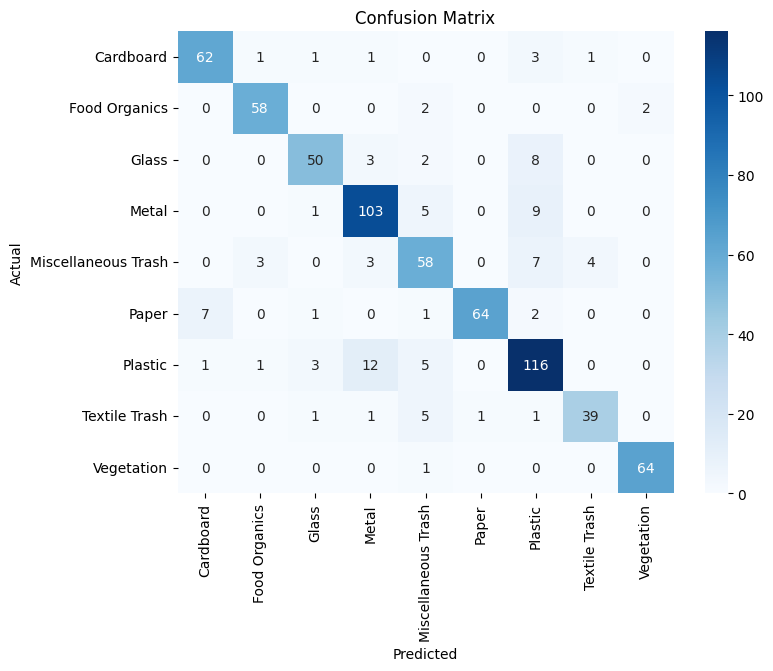


Evaluating VGG16 on Test Set...
Test Accuracy: 0.8429172510518934

Classification Report:
                      precision    recall  f1-score   support

          Cardboard       0.89      0.86      0.87        69
      Food Organics       0.94      0.94      0.94        62
              Glass       0.83      0.78      0.80        63
              Metal       0.75      0.91      0.82       118
Miscellaneous Trash       0.85      0.55      0.67        75
              Paper       0.87      0.91      0.89        75
            Plastic       0.83      0.80      0.81       138
      Textile Trash       0.77      0.96      0.85        48
         Vegetation       0.97      0.97      0.97        65

           accuracy                           0.84       713
          macro avg       0.86      0.85      0.85       713
       weighted avg       0.85      0.84      0.84       713



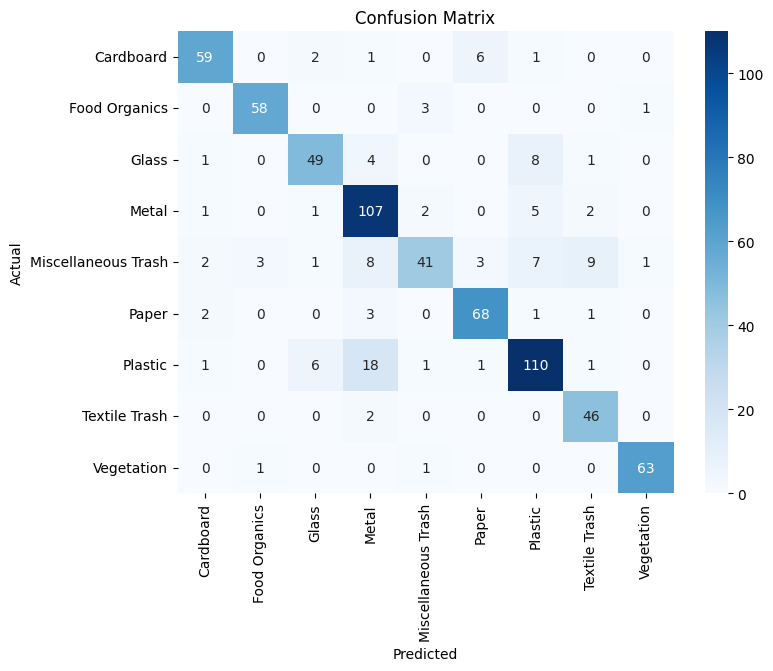

In [22]:

def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print("Test Accuracy:", acc)
    print("\nClassification Report:\n", classification_report(all_labels, all_preds, target_names=full_dataset.classes))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=full_dataset.classes,
                yticklabels=full_dataset.classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

print("\nEvaluating ResNet18 on Test Set...")
evaluate_model(resnet_model, test_loader)

print("\nEvaluating VGG16 on Test Set...")
evaluate_model(vgg_model, test_loader)
